# IIR Notch Filter 抗干扰性能演示

本 Notebook 展示 **IIR自适应陷波器（iir_notch）** 算法对以下两类干扰的抑制效果：
- 单音干扰（Single-Tone Interference）
- 窄带干扰（Narrowband Interference）

使用 `girk` 工具包生成干扰信号，并应用 `iir_notch` 进行抑制。

In [61]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, spectrogram

In [62]:
# 导入 girk 模块
from girk.interference.generators import single_tone_interference, narrowband_interference
from girk.mitigation import iir_notch

In [63]:
# 设置全局绘图风格
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (12, 4),
    'axes.grid': True
})

In [64]:
# =======  参数设置  =========
# 通用参数
fs = 21e6  # 采样率 (21 MHz)
duration = 0.01  # 信号时长 (10 ms)
noise_power = 1.0  # 热噪声功率

# 干扰参数
freq_offset = 1.5e6  # 干扰中心频偏 (1.5 MHz)
inr_db = 30.0            # 干噪比 (Interference-to-Noise Ratio, in dB)

inr_linear = 10**(inr_db / 10)   # 转换为线性值
interference_power = noise_power * inr_linear  # 干扰功率

## 1. 单音干扰场景

In [65]:
# %%
# 生成热噪声
# np.random.seed(42)  # 仅用于可复现性（实际仿真应移除）
t = np.arange(int(fs * duration)) / fs
noise = (np.random.randn(len(t)) + 1j * np.random.randn(len(t))) * np.sqrt(noise_power / 2)

In [66]:
# 生成单音干扰
tone = single_tone_interference(
    fs=fs, freq_offset=freq_offset, duration=duration,
    power=interference_power, dtype=np.complex64
)

In [67]:
# 合成接收信号
x_tone = noise + tone

In [68]:
# Apply IIR adaptive notch filter
# Note: iir_notch requires convergence time (~1000-5000 samples)
# iir_notch 参数
mu = 0.01        # learning rate
alpha = 0.9      # Narrower notch
y_tone, f_est_tone = iir_notch(
    x_tone, 
    fs=fs, 
    mu=mu,        # Adjusted learning rate
    alpha=alpha,      # Narrower notch
    return_freq_est=True
)

# Define convergence skip length (samples to discard at start)
convergence_skip = 21000 * 1  # 1 ms at 21 MHz
print(f"Single-tone interference scenario: input length = {len(x_tone)}, output length = {len(y_tone)}")

Single-tone interference scenario: input length = 210000, output length = 210000


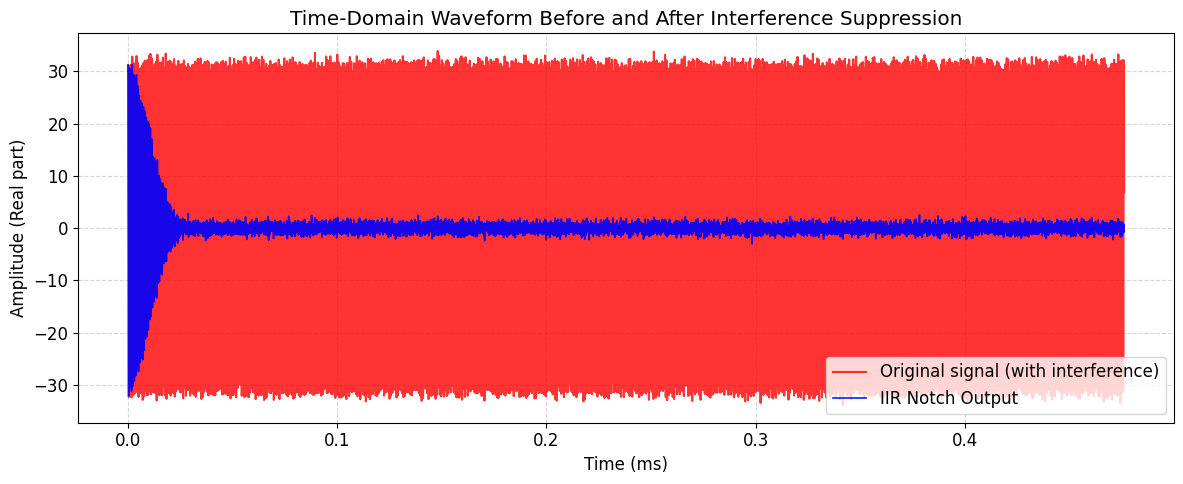

In [69]:
#  1.1 时域波形对比（实部）
samples_show = 10000  # Show more samples to see convergence
plt.figure(figsize=(12, 5))
plt.plot(t[:samples_show] * 1e3, np.real(x_tone[:samples_show]), 
         label='Original signal (with interference)', alpha=0.8, color='red')
plt.plot(t[:samples_show] * 1e3, np.real(y_tone[:samples_show]), 
         label='IIR Notch Output', alpha=0.9, color='blue', linewidth=1.2)
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (Real part)')
plt.title('Time-Domain Waveform Before and After Interference Suppression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

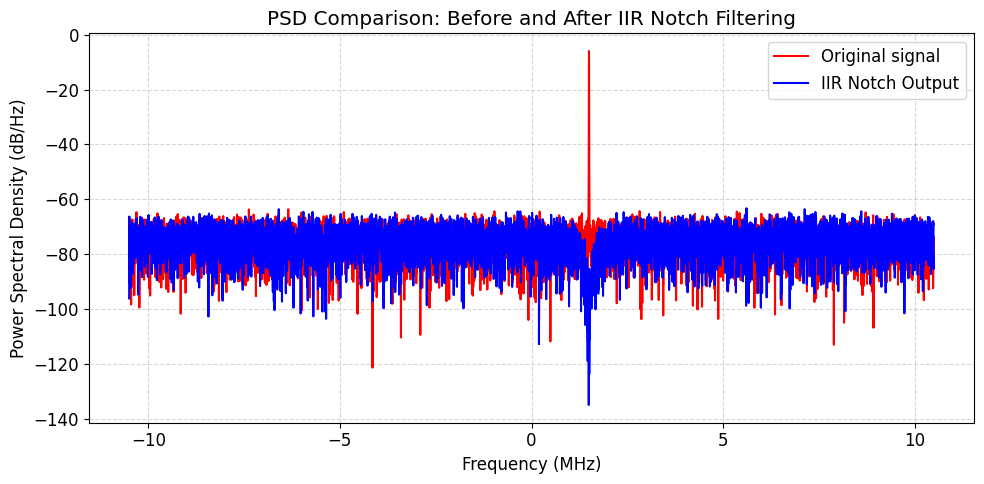

In [70]:
# # 1.2 功率谱密度（PSD）对比
def plot_psd(signal, fs, label, color='C0'):
    f, psd = welch(signal, fs=fs, nperseg=8192, return_onesided=False)
    # 转换为 dB-Hz（相对于 1 Hz 带宽）
    psd_db = 10 * np.log10(psd)
    # 频率搬移到 [-fs/2, fs/2]
    f_shifted = np.fft.fftshift(f)
    psd_db_shifted = np.fft.fftshift(psd_db)
    plt.plot(f_shifted / 1e6, psd_db_shifted, color=color, label=label)

plt.figure(figsize=(10, 5))
plot_psd(x_tone[:samples_show], fs, 'Original signal', 'red')
plot_psd(y_tone[convergence_skip:convergence_skip+samples_show], fs, 'IIR Notch Output', 'blue')  # Use full signal for PSD
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power Spectral Density (dB/Hz)')
plt.title('PSD Comparison: Before and After IIR Notch Filtering')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

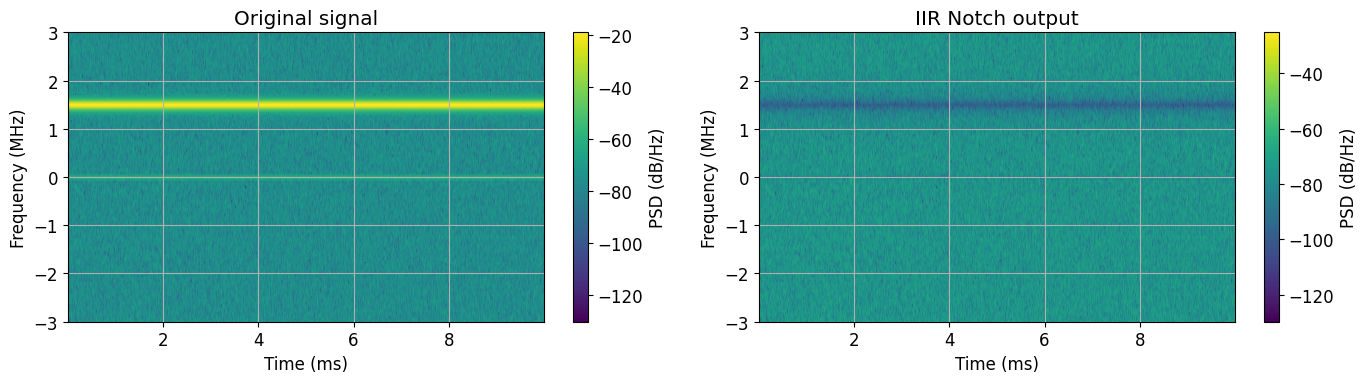

In [71]:
#  1.3 语谱图（Spectrogram）对比
def plot_spectrogram(signal, title, fs):
    f, t_spec, Sxx = spectrogram(
        signal, fs=fs, window='hann', nperseg=512,
        noverlap=256, return_onesided=False, scaling='density'
    )
    f = np.fft.fftshift(f)
    Sxx = np.fft.fftshift(Sxx, axes=0)

    plt.pcolormesh(t_spec * 1e3, f / 1e6, 10 * np.log10(Sxx),
                   shading='gouraud', cmap='viridis')
    plt.colorbar(label='PSD (dB/Hz)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Frequency (MHz)')
    plt.title(title)
    plt.ylim(-3, 3)

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plot_spectrogram(x_tone, 'Original signal', fs)
plt.subplot(1, 2, 2)
plot_spectrogram(y_tone, 'IIR Notch output', fs)
plt.tight_layout()
plt.show()

## 2. 窄带干扰场景

In [72]:
# %%
# 生成窄带干扰
narrow = narrowband_interference(
    fs=fs, freq_offset=freq_offset, bandwidth=100e3,  # 100 kHz 带宽
    duration=duration, power=interference_power, dtype=np.complex64
)

In [73]:
# 合成接收信号
x_narrow = noise + narrow

In [74]:
# Apply IIR adaptive notch filter
mu = 0.12       # learning rate
alpha = 0.8      # Narrower notch
y_narrow, f_est_narrow = iir_notch(
    x_narrow, 
    fs=fs, 
    mu=mu,        # Adjusted learning rate
    alpha=alpha,      # Narrower notch
    return_freq_est=True
)
convergence_skip = 21000 * 5  # 1 ms at 21 MHz

print(f"Narrowband interference scenario: input length = {len(x_tone)}, output length = {len(y_tone)}")

Narrowband interference scenario: input length = 210000, output length = 210000


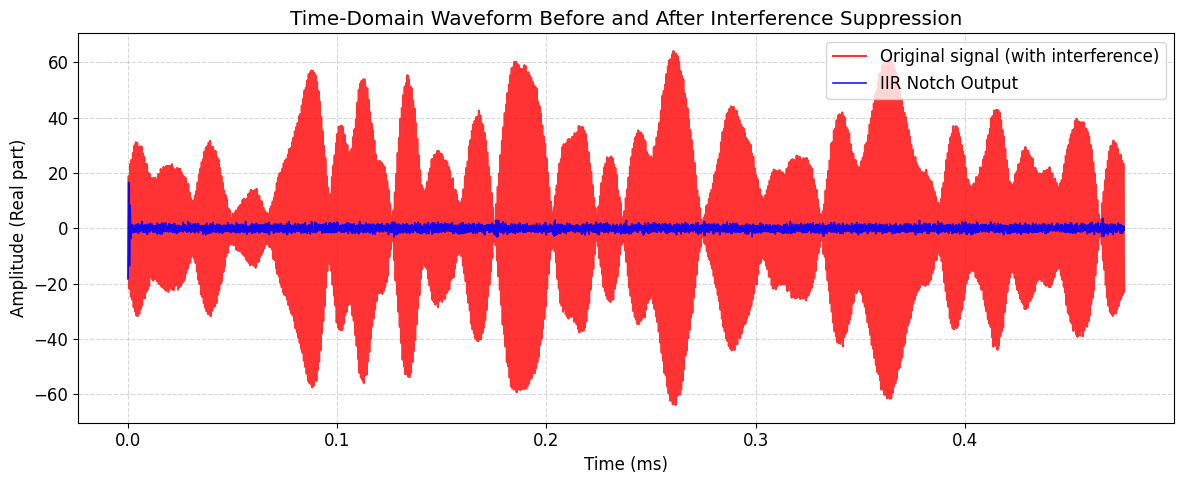

In [75]:
#  2.1 时域波形对比（实部）
plt.figure(figsize=(12, 5))
plt.plot(t[:samples_show] * 1e3, np.real(x_narrow[:samples_show]), 
         label='Original signal (with interference)', alpha=0.8, color='red')
plt.plot(t[:samples_show] * 1e3, np.real(y_narrow[:samples_show]), 
         label='IIR Notch Output', alpha=0.9, color='blue', linewidth=1.2)
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (Real part)')
plt.title('Time-Domain Waveform Before and After Interference Suppression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

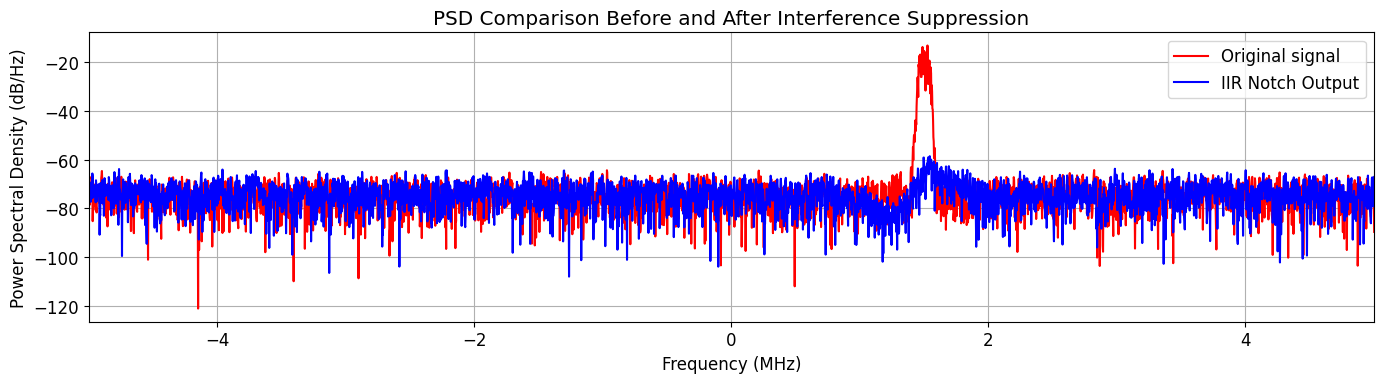

In [76]:
# # 2.2 功率谱密度（PSD）对比
def plot_psd(signal, fs, label, color='C0'):
    f, psd = welch(signal, fs=fs, nperseg=8192, return_onesided=False)
    # 转换为 dB-Hz（相对于 1 Hz 带宽）
    psd_db = 10 * np.log10(psd)
    # 频率搬移到 [-fs/2, fs/2]
    f_shifted = np.fft.fftshift(f)
    psd_db_shifted = np.fft.fftshift(psd_db)
    plt.plot(f_shifted / 1e6, psd_db_shifted, color=color, label=label)

plt.figure(figsize=(14, 4))
plot_psd(x_narrow[:samples_show], fs, 'Original signal', 'red')
plot_psd(y_narrow[convergence_skip:convergence_skip+samples_show], fs, 'IIR Notch Output', 'blue')  
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power Spectral Density (dB/Hz)')
plt.title('PSD Comparison Before and After Interference Suppression')
plt.legend()
plt.xlim(-5, 5)
plt.tight_layout()
plt.show()

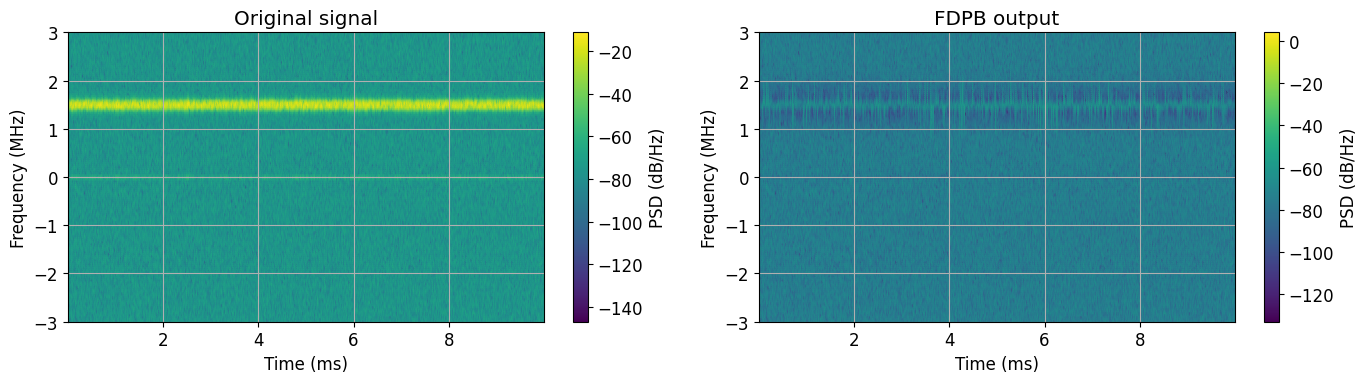

In [77]:
#  3.3 语谱图（Spectrogram）对比
def plot_spectrogram(signal, title, fs):
    f, t_spec, Sxx = spectrogram(
        signal, fs=fs, window='hann', nperseg=512,
        noverlap=256, return_onesided=False, scaling='density'
    )
    f = np.fft.fftshift(f)
    Sxx = np.fft.fftshift(Sxx, axes=0)

    plt.pcolormesh(t_spec * 1e3, f / 1e6, 10 * np.log10(Sxx),
                   shading='gouraud', cmap='viridis')
    plt.colorbar(label='PSD (dB/Hz)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Frequency (MHz)')
    plt.title(title)
    plt.ylim(-3, 3)

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plot_spectrogram(x_narrow, 'Original signal', fs)
plt.subplot(1, 2, 2)
plot_spectrogram(y_narrow, 'FDPB output', fs)
plt.tight_layout()
plt.show()

## 结论
- ✅ IIR Notch 能有效抑制单音干扰
- ✅ IIR Notch 对窄带干扰也有显著抑制效果，但干扰带宽越大，越难抑制，抑制效果不如FDPB，但算法复杂度很低  
- ⚠️ **注意**： alpha的设置是IIR Notch的关键：
- = 极点离单位圆越近（α → 1） → 系统 Q 值越高 → 陷波越窄、越深
- = 极点离原点越近（α → 0） → 系统带宽越宽 → 陷波变浅、变宽